In [3]:

import os
import scipy.io
import h5py
import numpy as np
import sys
from scipy import signal as sig
from scipy import stats as stats
import math
import pandas as pd
import csv
import matplotlib.pyplot as plt
from scipy import signal
import seaborn as sns
import logging

%matplotlib widget

scripts_path = '/home/apollo/Documents/github_projects/ripple_sync/scripts/hc_18_scripts/'
os.chdir(scripts_path)

import hc18_BaseFunctions as hc18_bf
import ripple_detection as ripple
import normalizing_functions as norm
import helper_functions as helper



In [4]:

sessions = ['Train-242-20140124','Train-261-20140617','Train-272-20141215','Train-292-20150501','Train-314-20160118']
animals = ['242','261','272','292','314']

sessions = ['Train-242-20140124']
animals = ['242']

In [7]:

event_name = 'SleepBaseline'
# event_name = 'PassiveForward'
    
output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['slope'] = []
output_dict['intercept'] = []
output_dict['r_value'] = []
output_dict['p_value'] = []
output_dict['std_err'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

for animal_idx,session in enumerate(sessions):

    print(session)
    
    lfp,srate = hc18_bf.load_lfp_hc18_data(session)
    
    event_times, event_descriptions = hc18_bf.get_events(session, event_name)
    
    event_times = np.sort(np.array(event_times))
    event_start = np.nanmin(event_times)
    event_end = np.nanmax(event_times)

    shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)
    
    filename = f'{scripts_path}/{session}_{event_name}_sleep_epochs.npy' 
    sleep_epochs = np.load(filename,allow_pickle=True).item()
    
    # lfp = np.double(lfp[:,sleep_epochs['sws_epochs']])
    # lfp = sig.detrend(helper.eegfilt(lfp,srate,0.1,0))


Train-242-20140124


In [8]:
ripple_features = ripple.get_ripple_info(lfp[8,:], srate, ripple_band=(100, 250),ripple_threshold_level = 2, 
                                 min_ripple_duration = 0.02, max_ripple_duration = 0.2, smooth_time = 0.005)
    

In [11]:
len(ripple_features['centers'])

2930

In [12]:
ripple_features.keys()

dict_keys(['centers', 'powers', 'cycles', 'minima', 'max_amplitudes'])

In [16]:
ripple_epoch = np.unique(np.concatenate(ripple_features['cycles']))


In [20]:
max_ripple_channels = []
for channels in shanks_electrodes:
    ripple_lfp = lfp[channels,:][:,ripple_epoch]
    ripple_filtered = sig.detrend(helper.eegfilt(ripple_lfp,srate,100,250))
    ripple_hilbert = helper.hilbert(ripple_filtered)
    ripple_amp = np.abs(ripple_hilbert)

    max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
    max_ripple_channels.append(channels[max_ripple_idx])
max_ripple_channels = np.array(max_ripple_channels)


In [45]:
max_ripple_channels

array([ 0,  7, 10, 12, 17, 21, 26, 31, 34, 39, 43, 47, 51, 55, 57, 60])

In [43]:

shank_1 = 0
ripple_lfp_1 = lfp[max_ripple_channels[shank_1],:]

ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
# ripple_phase_1 = np.angle(ripple_hilbert_1)
ripple_amp_1 = np.abs(ripple_hilbert_1)

shank_2 = 5
    
ripple_lfp_2 = lfp[max_ripple_channels[shank_2],:]

ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
# ripple_phase_2 = np.angle(ripple_hilbert_2)
ripple_amp_2 = np.abs(ripple_hilbert_2)


amp_window_length = 0.05*srate
non_overlap = 0.01*srate
overlap = amp_window_length-non_overlap
binned_amplitude_1 = []
binned_amplitude_2 = []

for ll in np.arange(0,((ripple_lfp_1.shape[0]-amp_window_length)/non_overlap)):
    amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)

    binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
    binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))

binned_amplitude_1 = np.array(binned_amplitude_1)
binned_amplitude_2 = np.array(binned_amplitude_2)

slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)
r_value

-0.0043492076439758985

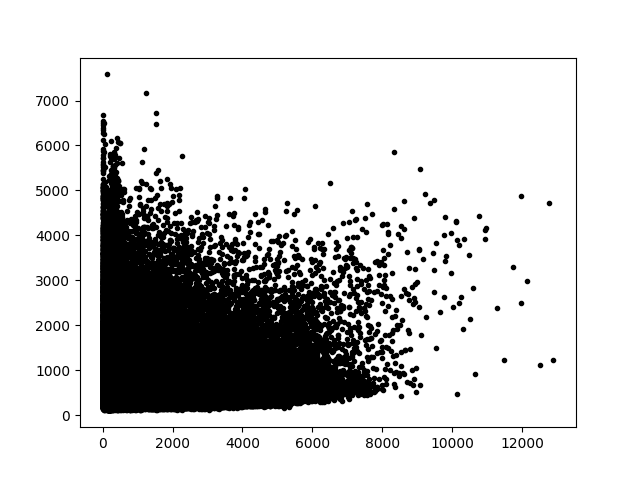

In [44]:
plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.show()

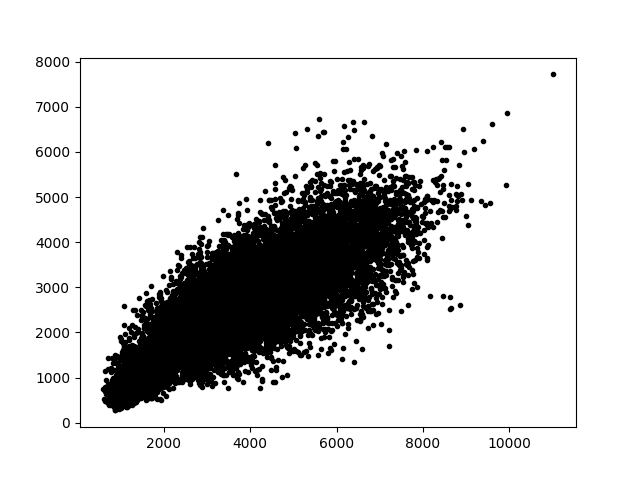

In [40]:
plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.show()

In [2]:

event_name = 'SleepBaseline'
# event_name = 'PassiveForward'
    
output_dict = dict()
output_dict['rat'] = []
output_dict['session'] = []
output_dict['side'] = []
output_dict['shank_1'] = []
output_dict['shank_2'] = []
output_dict['slope'] = []
output_dict['intercept'] = []
output_dict['r_value'] = []
output_dict['p_value'] = []
output_dict['std_err'] = []

srate = 1250.
ripple_threshold_level = 2
ripple_low_freq = 100
ripple_high_freq = 250
minimum_ripple_length = 0.03*srate
smooth_points = 0.001*srate

for animal_idx,session in enumerate(sessions):

    print(session)
    
    lfp,srate = hc18_bf.load_lfp_hc18_data(session)
    
    event_times, event_descriptions = hc18_bf.get_events(session, event_name)
    
    event_times = np.sort(np.array(event_times))
    event_start = np.nanmin(event_times)
    event_end = np.nanmax(event_times)

    shanks_electrodes,left_shanks,right_shanks = hc18_bf.get_shanks_info(session)
    
    filename = f'{scripts_path}/{session}_{event_name}_sleep_epochs.npy' 
    sleep_epochs = np.load(filename,allow_pickle=True).item()
    
    lfp = np.double(lfp[:,sleep_epochs['sws_epochs']])
    lfp = sig.detrend(helper.eegfilt(lfp,srate,0.1,0))

    max_ripple_channels = []
    for channels in shanks_electrodes:
        ripple_lfp = lfp[channels,:].copy()
        ripple_filtered = sig.detrend(helper.eegfilt(ripple_lfp,srate,100,250))
        ripple_hilbert = helper.hilbert(ripple_filtered)
        ripple_amp = np.abs(ripple_hilbert)
    
        max_ripple_idx = np.argmax(np.nanmean(ripple_amp,1))
        max_ripple_channels.append(channels[max_ripple_idx])
    max_ripple_channels = np.array(max_ripple_channels)

    for shank_1 in np.arange(0,len(shanks_electrodes)-1):    
        
        print('Shank 1 = ' + str(shank_1))

        ripple_lfp_1 = lfp[max_ripple_channels[shank_1],:].copy()

        ripple_filtered_1 = sig.detrend(helper.eegfilt(ripple_lfp_1,srate,100,250))
        ripple_hilbert_1 = helper.hilbert(ripple_filtered_1)
        # ripple_phase_1 = np.angle(ripple_hilbert_1)
        ripple_amp_1 = np.abs(ripple_hilbert_1)

        for shank_2 in np.arange(shank_1+1,len(shanks_electrodes)):
                
            ripple_lfp_2 = lfp[max_ripple_channels[shank_2],:].copy()

            ripple_filtered_2 = sig.detrend(helper.eegfilt(ripple_lfp_2,srate,100,250))
            ripple_hilbert_2 = helper.hilbert(ripple_filtered_2)
            # ripple_phase_2 = np.angle(ripple_hilbert_2)
            ripple_amp_2 = np.abs(ripple_hilbert_2)


            amp_window_length = 0.05*srate
            non_overlap = 0.01*srate
            overlap = amp_window_length-non_overlap
            binned_amplitude_1 = []
            binned_amplitude_2 = []
    
            for ll in np.arange(0,((ripple_lfp_1.shape[0]-amp_window_length)/non_overlap)):
                amp_window = np.arange((amp_window_length-overlap)*ll,(amp_window_length-overlap)*ll + amp_window_length).astype(int)
    
                binned_amplitude_1.append(np.nanmean(ripple_amp_1[amp_window]))
                binned_amplitude_2.append(np.nanmean(ripple_amp_2[amp_window]))
    
            binned_amplitude_1 = np.array(binned_amplitude_1)
            binned_amplitude_2 = np.array(binned_amplitude_2)
    
            slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)

            
            if ((shank_1 in left_shanks) & (shank_2 in left_shanks)) | ((shank_1 in right_shanks) & (shank_2 in right_shanks)):
                side = 'ipsi'
            else:
                side = 'contra'
            

            
            output_dict['rat'].append(animals[animal_idx])
            output_dict['session'].append(session)
            output_dict['side'].append(side)
            output_dict['shank_1'].append(shank_1)
            output_dict['shank_2'].append(shank_2)
            output_dict['slope'].append(slope)
            output_dict['intercept'].append(intercept)
            output_dict['r_value'].append(r_value)
            output_dict['p_value'].append(p_value)
            output_dict['std_err'].append(std_err)            

df = pd.DataFrame(output_dict)
df

path = "/home/apolo/Documents/github_projects/ripple_sync/results/"
os.chdir(path)

df.to_csv('Figure_Ripple_AmpAmpCoupling_WholeSignal_hc18.csv',index=False)


Train-242-20140124
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-261-20140617
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-272-20141215
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-292-20150501
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 1 = 13
Shank 1 = 14
Train-314-20160118
Shank 1 = 0
Shank 1 = 1
Shank 1 = 2
Shank 1 = 3
Shank 1 = 4
Shank 1 = 5
Shank 1 = 6
Shank 1 = 7
Shank 1 = 8
Shank 1 = 9
Shank 1 = 10
Shank 1 = 11
Shank 1 = 12
Shank 

In [10]:
slope, intercept, r_value, p_value, std_err = stats.linregress(binned_amplitude_1,binned_amplitude_2)
r_value

0.4474424677829363

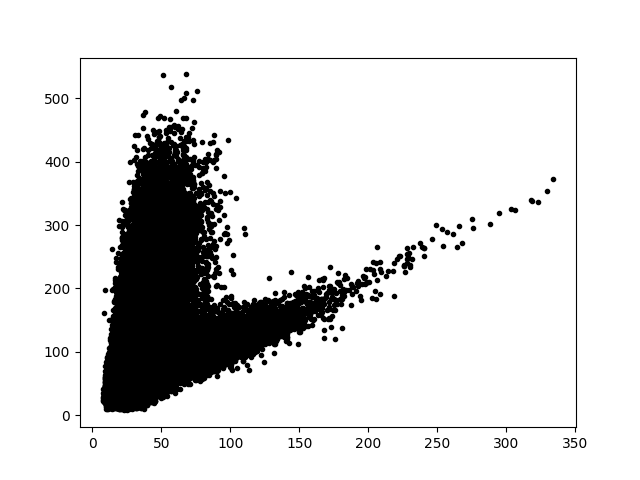

In [12]:
plt.figure()
plt.plot(binned_amplitude_1,binned_amplitude_2,'k.')
plt.show()

/tmp/ipykernel_23154/2566655912.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


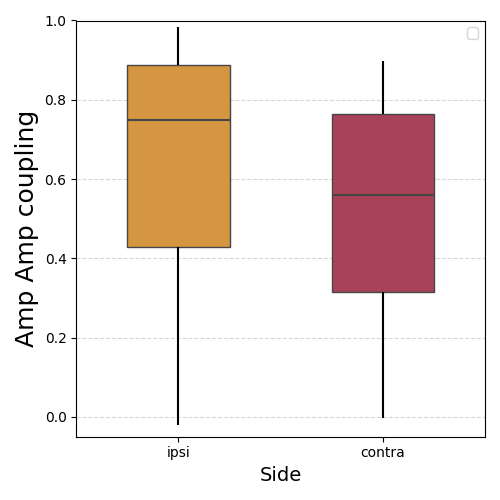

In [7]:

plt.close('all')
plt.figure(figsize=(5,5))

my_pal ={"ipsi": "#ec9a29","contra":"#b9314f"}

# sns.stripplot(data=df, x="side", y="r_value", hue='side',
#               order=["ipsi", "contra"], palette=my_pal,size=6,alpha=1)

box = sns.boxplot(data=df, x="side", y="r_value", hue='side',
            order=['ipsi','contra'], showfliers=False, showcaps=False,palette=my_pal,
            whiskerprops=dict(linestyle='-', linewidth=1.5, color='black'),
            medianprops=dict(linestyle='-', linewidth=1.5),
            width=0.5)  # Using the custom color palette

# ax=sns.violinplot(data=df,x="side", y="r_value", hue='side',
#                 order=["ipsi", "contra"], palette=my_pal,fill=True,inner = None,\
#                 split=True, density_norm='width',saturation=1,bw_adjust=0.5,native_scale=True)
# plt.setp(ax.collections, alpha=.3)

plt.ylabel('Amp Amp coupling',fontsize=18)
plt.xlabel('Side',fontsize=14)
plt.grid(linestyle='--',alpha=0.5,axis='y')
# plt.legend([], [], frameon=False)
plt.ylim([-0.05,1])
plt.legend()
# we need to set it manually so we will be able to edit them ticks in inkscape as a path (otherwise, we need to set it as a "object to path")
# plt.xticks([0,1],labels=['Left','Right'])
plt.tight_layout()

# os.chdir(figures_path + '/figure_3/')
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_WholeSignal.svg'
# fig_name = 'Figure_Ripple_PhasePhaseCoupling_RippleEvents.svg'

# plt.savefig(fig_name,transparent=False,format='svg', bbox_inches = 'tight')
plt.show()
# hf.delete_clip_path(fi_name)

